## Problem Statement

### House Price Prediction Using Machine Learning

The real estate market is influenced by numerous factors such as property size, location, construction quality, number of rooms, and various neighborhood characteristics. Determining the correct selling price of a house can be challenging for homeowners, buyers, and real estate agencies, as inaccurate pricing may lead to financial losses or prolonged selling periods.

This project aims to develop a Machine Learning model capable of predicting residential property prices based on various housing features from the Ames Housing Dataset. By analyzing historical housing data and identifying the factors that most influence property value, the model seeks to provide accurate price estimates that can support data-driven decision-making in the real estate sector.

The project involves data preprocessing, exploratory data analysis, feature engineering, model training, and performance evaluation using multiple regression algorithms. The final objective is to identify the most effective model for predicting house prices while gaining insights into the key factors that drive property valuation.

### Objective
- Analyze housing data to understand the factors affecting house prices.
- Clean and preprocess the dataset for model development.
- Build and compare multiple Machine Learning regression models.
- Evaluate model performance using RMSE, MAE, and R² Score.
- Identify the most important features influencing house prices.
- Develop a reliable predictive model for estimating residential property values.

In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

In [180]:
data = pd.read_csv('AmesHousing.csv')

In [181]:
drop_cols = [
    'Garage Type',
    'Mas Vnr Type',
    'Alley',
    'Fence',
    'Misc Feature',
    'Order',
    'PID',
    'Utilities'
]

In [182]:
data = data.drop(columns=drop_cols)

## EDA

### Distribution of Target Variable - SalePrice

<Axes: xlabel='SalePrice', ylabel='Count'>

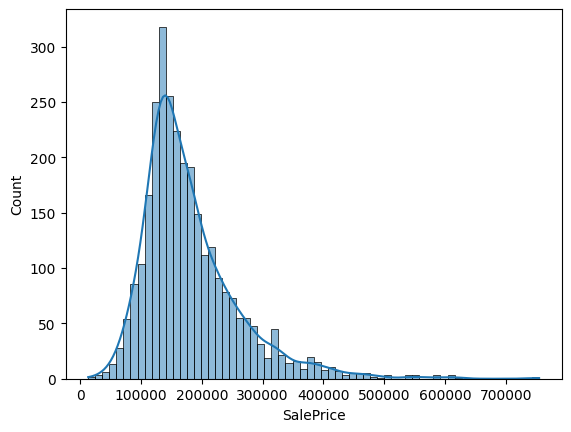

In [183]:
sns.histplot(data['SalePrice'], kde=True)

In [184]:
data['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

Findings:
- The target variable SalePrice is positively skewed (right-skewed), with most of the houses priced between ₹100,000 and ₹250,000, while a few high-priced houses are the reason for a long right tail.

- The mean sale price (180,796) is higher than the median (160,000), confirming the presence of high-value outliers.

- The middle 50% of house prices lie between 129,500 (Q1) and 213,500 (Q3), showing that most houses are concentrated within this range.

### Checking the 15 Strongest Linear Relationship features with target variable

In [185]:
corr = data.corr(numeric_only=True)

In [186]:
target_col = 'SalePrice'  
top_features = corr[target_col].abs().sort_values(ascending=False).iloc[1:16].index

filtered_matrix = data[[target_col] + list(top_features)].corr(numeric_only=True)

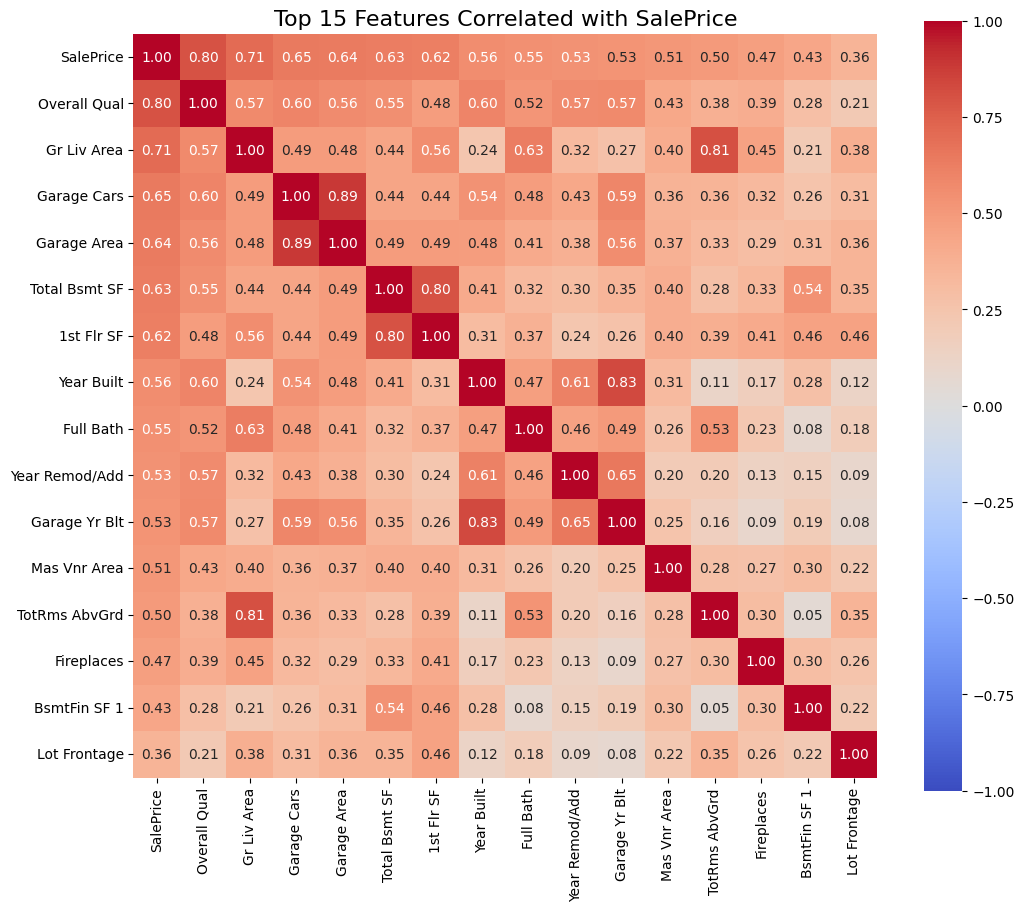

In [187]:
plt.figure(figsize=(12, 10))
sns.heatmap(filtered_matrix, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            center=0, 
            fmt='.2f',
            square=True)

plt.title(f'Top 15 Features Correlated with {target_col}', fontsize=16)
plt.show()

In [188]:
corr['SalePrice'].sort_values(ascending=False).head(16)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Lot Frontage      0.357318
Name: SalePrice, dtype: float64

Findings:
- `Overall Quality` (0.80) has the strongest positive correlation with `SalePrice`, indicating that better-quality homes generally command higher prices.
- `Above-Ground Living Area` (Gr Liv Area, 0.71), `Garage Capacity` (0.65), `Garage Area` (0.64), and `Total Basement Area` (0.63) are also strongly associated with higher house prices.
- Newer homes tend to be more expensive, as shown by the positive correlations of `Year Built` (0.56) and `Year Remodeled/Added` (0.53) with SalePrice.
- Several features are highly correlated with each other (e.g., Garage Cars & Garage Area = 0.89, Year Built & Garage Year Built = 0.83).

### Checking how different categorical columns affect SalePrice

<Axes: xlabel='Kitchen Qual', ylabel='SalePrice'>

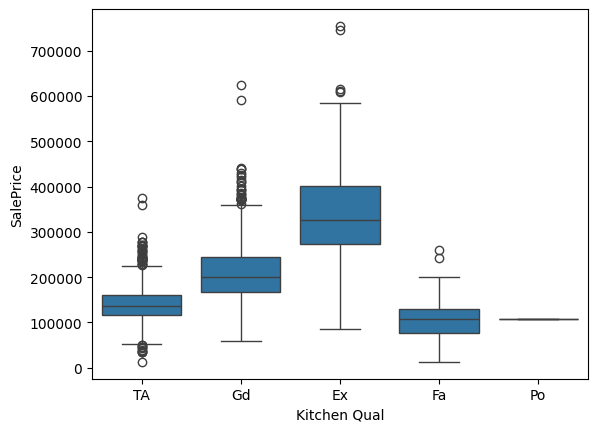

In [189]:
sns.boxplot(x='Kitchen Qual', y='SalePrice', data=data)

- Better Kitchen Quality corresponds to significantly higher sale prices.
- Houses with Excellent kitchens (Ex) have the highest median property values.
- Properties with Fair or Poor kitchen quality are concentrated in lower price ranges.
- Kitchen quality appears to be a strong predictor of house prices and buyer willingness to pay.

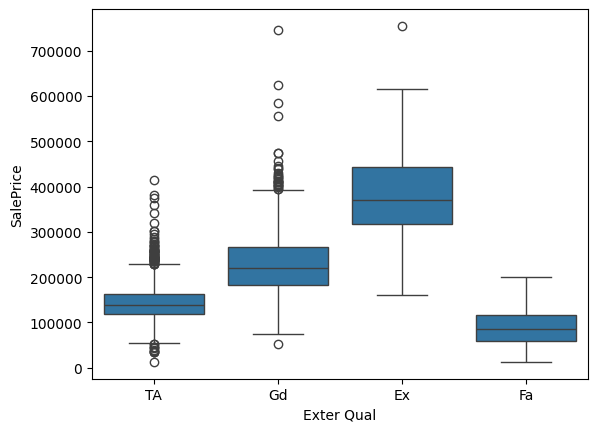

In [190]:
sns.boxplot(x='Exter Qual', y='SalePrice', data=data)
plt.show()

- Houses with Excellent exterior quality (Ex) achieve the highest sale prices.
- A clear upward trend exists from Fair (Fa) → Typical (TA) → Good (Gd) → Excellent (Ex).
- Higher exterior quality is associated with both higher median prices and premium outlier properties.
- Exterior quality is one of the most influential categorical features affecting SalePrice.

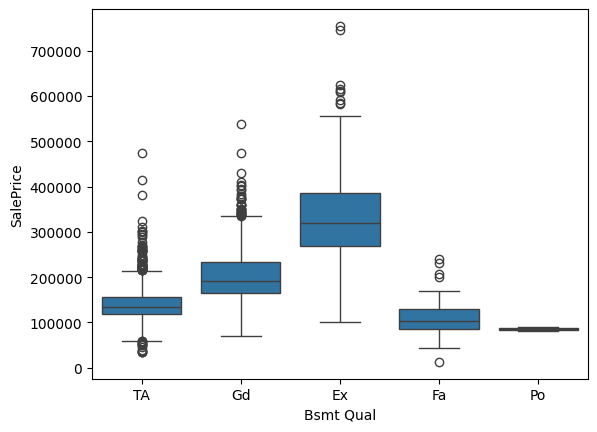

In [191]:
sns.boxplot(x='Bsmt Qual', y='SalePrice', data=data)
plt.show()

- SalePrice increases substantially as Basement Quality improves from Fair (Fa) to Excellent (Ex).
- Houses with Excellent basements have the highest median and maximum prices.
- Properties with Poor or Fair basement quality are concentrated in lower price ranges.
- Basement quality is a strong indicator of overall home value.

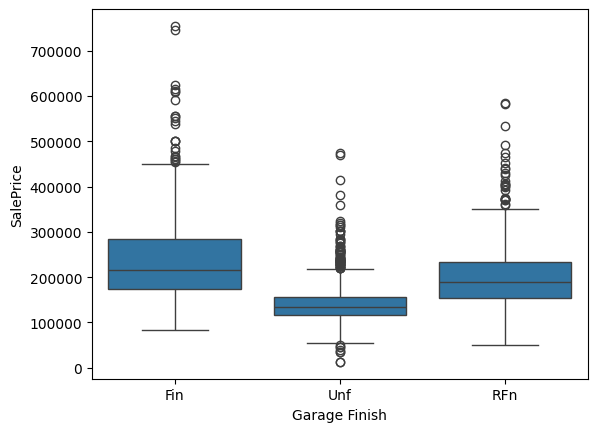

In [192]:
sns.boxplot(x='Garage Finish', y='SalePrice', data=data)
plt.show()

- Houses with Finished (Fin) garages have the highest median sale prices.
- Rough Finished (RFn) garages also show relatively high property values.
- Houses with Unfinished (Unf) garages generally sell for lower prices.
- Better garage finishing appears to positively impact house prices.

### Checking the distribution of Numerical columns against target variable

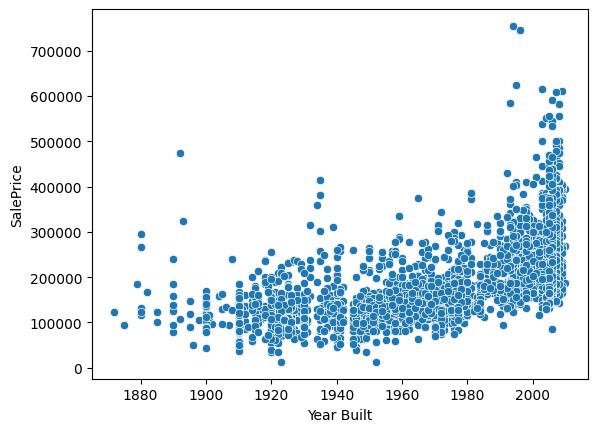

In [193]:
sns.scatterplot(x='Year Built', y ='SalePrice', data=data)
plt.show()

- Newer homes generally command higher sale prices than older properties.

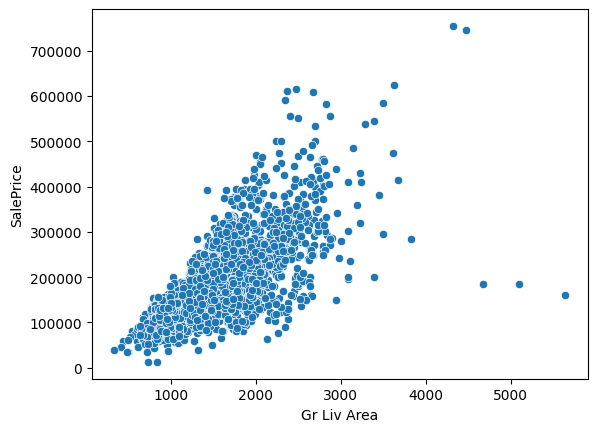

In [194]:
sns.scatterplot(x='Gr Liv Area', y ='SalePrice', data=data)
plt.show()

- Clear positive relationship between living area and SalePrice, with larger homes generally selling for more.
- Most properties are clustered between 1,000–2,500 sq ft and $100,000–$300,000.

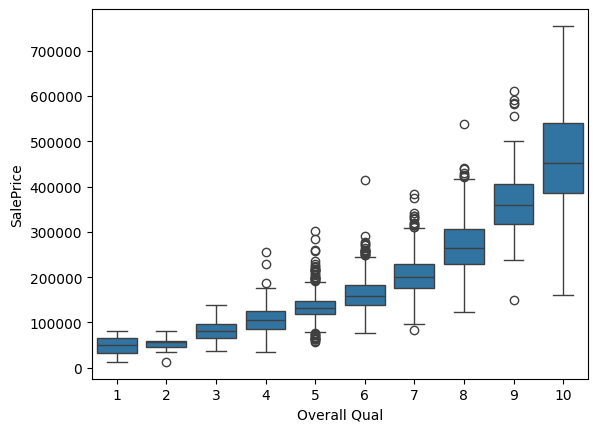

In [195]:
sns.boxplot(y = data['SalePrice'] ,x = data['Overall Qual'])
plt.show()

- SalePrice increases consistently with higher Overall Quality ratings, showing a strong positive relationship.
- Houses rated 8–10 have significantly higher median prices compared to lower-rated properties.

### Splitting Columns

In [196]:
X = data.drop('SalePrice', axis=1)
y = np.log1p(data['SalePrice'])

In [197]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Columns divided as per required missing strategy

In [198]:
missing_none = ['Pool QC', 'Fireplace Qu', 'Bsmt Qual', 'Bsmt Cond', 'Garage Finish', 'Garage Qual', 
                'Garage Cond', 'BsmtFin Type 2', 'BsmtFin Type 1']

In [199]:
most_frequent = ['Electrical', 'Garage Cars']

In [200]:
as_zero = ['Bsmt Full Bath', 'Bsmt Half Bath', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Mas Vnr Area']

In [201]:
median_col = ['Lot Frontage', 'Garage Yr Blt', 'Garage Area']

In [202]:
bsmt_col = ['Bsmt Exposure']

### Handling Missing Values

In [203]:
def imputing_missing_values(X_train, X_test):

    #Filling with None
    X_train[missing_none] = X_train[missing_none].fillna('None')
    X_test[missing_none] = X_test[missing_none].fillna('None')

    #Filling with most frequent
    for col in most_frequent:
        mode = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode)
        X_test[col] = X_test[col].fillna(mode)

    #Filling with zero
    X_train[as_zero] = X_train[as_zero].fillna(0)
    X_test[as_zero] = X_test[as_zero].fillna(0)

    #Filling with median
    for col in median_col:
        median_value = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_value)
        X_test[col] = X_test[col].fillna(median_value)

    #Filling Bsmt column
    X_train[bsmt_col] = X_train[bsmt_col].fillna('No Basement')
    X_test[bsmt_col] = X_test[bsmt_col].fillna('No Basement')

    return X_train, X_test

In [204]:
X_train, X_test = imputing_missing_values(X_train, X_test)

In [205]:
X_train.isnull().sum().sum()

np.int64(0)

### Ordinal columns 

In [206]:
qual_with_none_columns = [
    'Bsmt Qual',
    'Bsmt Cond',
    'Pool QC',
    'Fireplace Qu',
    'Garage Qual',
    'Garage Cond'
]

In [207]:
quality_columns = [
    'Exter Qual',
    'Exter Cond',
    'Kitchen Qual',
    'Heating QC',
]

In [208]:
functional_column = ['Functional']
garage_column = ['Garage Finish']
paved_column = ['Paved Drive']
bsmt_exposure_column = ['Bsmt Exposure']
finish_column = ['BsmtFin Type 1', 'BsmtFin Type 2']

### Ordinal Encoding Columns

In [209]:
ordinal_categories = {
    'quality': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'none_quality': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'garage_finish': ['None', 'Unf', 'RFn', 'Fin'],
    'functional': ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'paved_drive': ['N', 'P', 'Y'],
    'bsmt_exposure': ['No Basement', 'No', 'Mn', 'Av', 'Gd'],
    'finish': ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
}

### One Hot Encoding Columns

In [210]:
nominal_cols = ['Neighborhood', 'MS Zoning', 'House Style', 'Condition 1', 'Condition 2', 'Bldg Type', 'Street', 
                'Lot Config', 'Roof Style', 'Exterior 1st', 'Exterior 2nd', 'Foundation', 'Heating', 'Sale Type', 
                'Sale Condition', 'Lot Shape', 'Land Contour', 'Land Slope', 'Roof Matl', 'Central Air', 'Electrical']

### Encoding

In [211]:
encoder = ColumnTransformer(
    transformers = [
        (
            'quality',
            OrdinalEncoder(
                categories = [ordinal_categories['quality']] * len(quality_columns)
            ),
            quality_columns
        ),
        
        (
            'none_column_quality',
            OrdinalEncoder(
                categories = [ordinal_categories['none_quality']] * len(qual_with_none_columns)
            ),
            qual_with_none_columns
        ),
        
        (
            'garage_finish',
            OrdinalEncoder(
                categories = [ordinal_categories['garage_finish']]
            ),
            garage_column
        ),
        
        (
            'functional',
            OrdinalEncoder(
                categories = [ordinal_categories['functional']]
            ),
            functional_column
        ),
        
        (
            'paved_drive',
            OrdinalEncoder(
                categories = [ordinal_categories['paved_drive']] 
            ),
            paved_column
        ),
        
        (
            'basement_exposure',
            OrdinalEncoder(
                categories = [ordinal_categories['bsmt_exposure']]
            ),
            bsmt_exposure_column
        ),

        (
            'finish',
            OrdinalEncoder(
                categories = [ordinal_categories['finish']] * len(finish_column)
            ),
            finish_column
        ),
        
        (
            'nominal_encoding',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            nominal_cols
        )
], remainder='passthrough')

## Model Building

### Linear Regression

In [212]:
X_train_transform = encoder.fit_transform(X_train)
X_test_transform = encoder.transform(X_test)

In [213]:
lr = LinearRegression()

In [214]:
lr.fit(X_train_transform, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [215]:
y_pred_log_lr = lr.predict(X_test_transform)

In [216]:
y_pred_lr = np.expm1(y_pred_log_lr)
y_actual = np.expm1(y_test)

In [217]:
RMSE = root_mean_squared_error(y_actual, y_pred_lr)
MAE = mean_absolute_error(y_actual, y_pred_lr)
R2 = r2_score(y_actual, y_pred_lr)

In [218]:
print('RMSE: ', RMSE)
print('MAE: ', MAE)
print('R²: ',R2)

RMSE:  34011.05129122651
MAE:  14835.267932611267
R²:  0.8557225201641581


What does these results mean?

**R² = 0.856:**
- The model explains approximately 85.6% of the variance in house prices.
- Indicates strong predictive performance for a simple linear model.

**MAE = $14,835:**
- On average, predictions differ from actual sale prices by about $14.8k.

**RMSE = $34,011:**
- Larger than MAE, suggesting some higher-error predictions or outliers still exist

#### Visualization of Linear Regressor

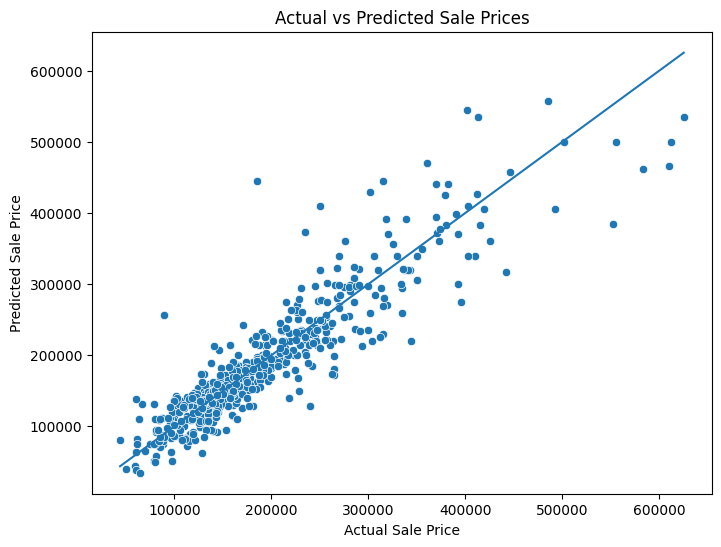

In [219]:
# Actual vs Predicted Sale Prices
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_actual,
    y=y_pred
)

plt.plot(
    [y_actual.min(), y_actual.max()],
    [y_actual.min(), y_actual.max()],
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Prices")

plt.show()

**Actual vs Predicted Prices**

Most observations lie close to the diagonal reference line, showing that the model's predictions are generally close to the actual sale prices.

Some larger deviations are observed among higher-priced houses, suggesting that luxury houses are more difficult for the model to predict accurately.

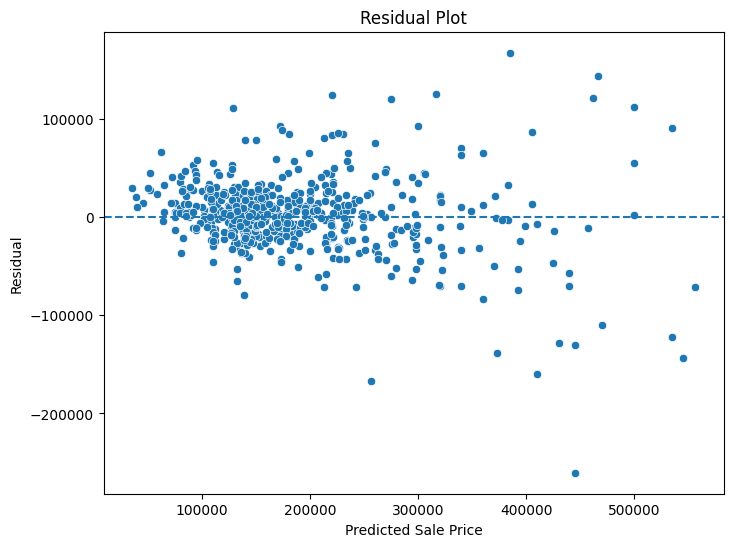

In [220]:
# Residual Plot
residuals = y_actual - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

**Residual Analysis**

Residuals are generally centered around zero, indicating that the model is not systematically overestimating or underestimating house prices.

A wider spread of residuals at higher predicted prices suggests increased prediction uncertainty for expensive houses.

In [221]:
# Top Coefficients
feature_names = encoder.get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)


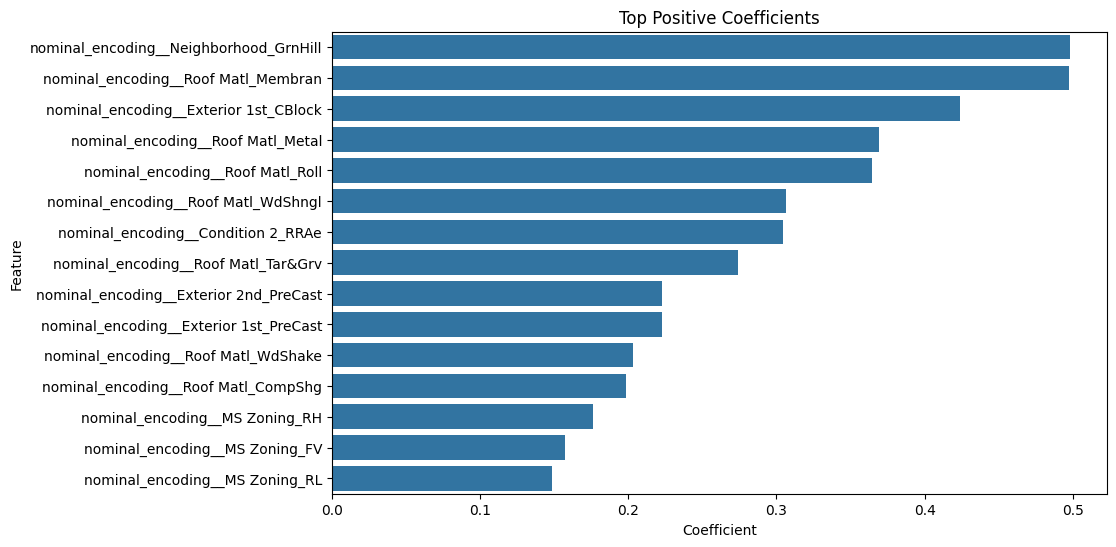

In [222]:
top_coef = coef_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_coef,
    x='Coefficient',
    y='Feature'
)

plt.title("Top Positive Coefficients")

plt.show()

**Feature Importance (Linear Regression Coefficients)**

Features with larger positive coefficients contribute more strongly to increasing predicted house prices.

Quality-related features, neighborhood characteristics, living area, and garage-related attributes show some of the strongest impacts on model predictions.

### Decision Tree

In [223]:
dt = DecisionTreeRegressor(random_state=42)

In [224]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [225]:
grid.fit(X_train_transform, y_train)

Fitting 5 folds for each of 336 candidates, totalling 1680 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [226]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}

Best CV Score:
0.787031687970156


In [227]:
best_dt = grid.best_estimator_

In [228]:
y_pred_log_dt = best_dt.predict(X_test_transform)

In [229]:
y_pred_dt = np.expm1(y_pred_log_dt)

In [230]:
RMSE = root_mean_squared_error(y_actual, y_pred_dt)
MAE = mean_absolute_error(y_actual, y_pred_dt)
R2 = r2_score(y_actual, y_pred_dt)

In [231]:
print('RMSE: ', RMSE)
print('MAE: ', MAE)
print('R²: ',R2)

RMSE:  35659.90309664432
MAE:  22682.199126899635
R²:  0.8413943140944731


A tuned Decision Tree Regressor achieved an R² score of 0.841. Despite hyperparameter optimization, it did not outperform the Linear Regression model (R² = 0.856). This suggests that the relationship between the features and house prices is largely captured through linear trends rather than complex nonlinear interactions.

### Random Forest

In [232]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [233]:
rf.fit(X_train_transform, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [234]:
y_pred_log_rf = rf.predict(X_test_transform)

In [235]:
y_pred_rf = np.expm1(y_pred_log_rf)

In [236]:
RMSE = root_mean_squared_error(y_actual, y_pred_rf)
MAE = mean_absolute_error(y_actual, y_pred_rf)
R2 = r2_score(y_actual, y_pred_rf)

In [237]:
print('RMSE: ', RMSE)
print('MAE: ', MAE)
print('R²: ',R2)

RMSE:  27451.827763299487
MAE:  16098.427733629356
R²:  0.9060058194799546


In [238]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

In [239]:
importance_df.head(5)

,Feature,Importance
183,remainder__Overall Qual,0.580995
195,remainder__Gr Liv Area,0.089533
206,remainder__Garage Area,0.039938
205,remainder__Garage Cars,0.039503
191,remainder__Total Bsmt SF,0.031592


While Linear Regression achieved a strong performance with R² score of 0.856, coefficient analysis was difficult to interpret due to multicollinearity and the presence of numerous one hot encoded categorical variables. However, Random Forest achieved superior predictive performance with R² score of 0.90 and identified that Overall Quality is the dominant predictor, contributing approximately 58% of total feature importance. Living area, garage characteristics, and basement area were also among the most influential features.

### Model Comparision

| Model             | RMSE       | MAE    | R²        |
| ----------------- | ---------- | ------ | --------- |
| Linear Regression | 34,011     | 14,835 | 0.856     |
| Decision Tree     | 35,660     | 22,682 | 0.841     |
| Random Forest     | **27,452** | 16,098 | **0.906** |